# Titanic Survival Prediction

Proyek ini membangun model machine learning untuk memprediksi apakah penumpang Titanic selamat atau tidak berdasarkan data pada `train.csv` dan `test.csv`.

Notebook disusun untuk kebutuhan laporan praktikum, sehingga setiap tahap diberi penjelasan singkat dan alur pengerjaan dibuat bertahap dari EDA hingga prediksi akhir.

In [ ]:
# Import library utama
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## A. Import Library

Pada tahap ini kita menyiapkan library yang dibutuhkan untuk pengolahan data, visualisasi, dan pembuatan model machine learning.

## B. Load Dataset

Dataset yang digunakan adalah `train.csv` sebagai data latih dan `test.csv` sebagai data uji. File berada di folder proyek yang sama dengan notebook sehingga cukup dipanggil langsung dengan nama file.

In [2]:
# Memuat data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print('Data train shape:', train_df.shape)
print('Data test shape:', test_df.shape)

display(train_df.head())
display(test_df.head())

Data train shape: (891, 12)
Data test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## C. Exploratory Data Analysis (EDA)

EDA digunakan untuk memahami struktur data, melihat pola awal, dan mencari indikasi fitur yang berpengaruh terhadap keselamatan penumpang.

In [3]:
# Menampilkan informasi dasar dataset
print('Shape train:', train_df.shape)
print('Shape test:', test_df.shape)

print('Info train:')
train_df.info()

print('Deskripsi statistik train:')
display(train_df.describe())

print('Missing values train:')
display(train_df.isnull().sum().to_frame('missing_values'))

print('Missing values test:')
display(test_df.isnull().sum().to_frame('missing_values'))

Shape train: (891, 12)
Shape test: (418, 11)
Info train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Deskripsi statistik train:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Missing values train:


,missing_values
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Missing values test:


,missing_values
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17252\3187613911.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Survived', palette='Set2')


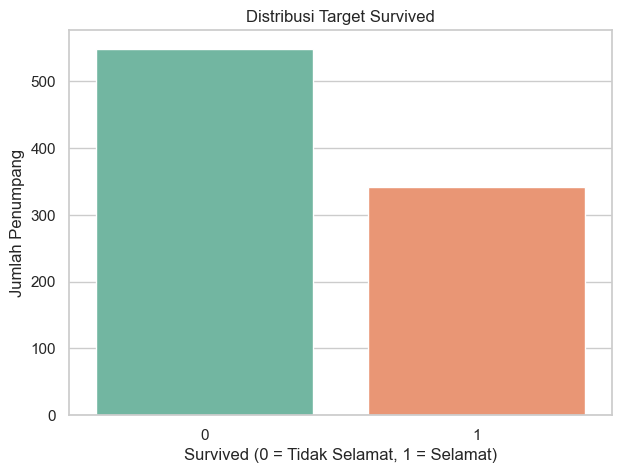

Penjelasan: Grafik ini menunjukkan keseimbangan kelas target. Jika satu kelas lebih banyak, model perlu memperhatikan ketidakseimbangan data.


In [4]:
# Visualisasi distribusi target Survived
plt.figure(figsize=(7, 5))
sns.countplot(data=train_df, x='Survived', palette='Set2')
plt.title('Distribusi Target Survived')
plt.xlabel('Survived (0 = Tidak Selamat, 1 = Selamat)')
plt.ylabel('Jumlah Penumpang')
plt.show()
print('Penjelasan: Grafik ini menunjukkan keseimbangan kelas target. Jika satu kelas lebih banyak, model perlu memperhatikan ketidakseimbangan data.')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17252\1008427854.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sex_survival_rate, x='Sex', y='Survived', palette='Set2', ax=axes[1])


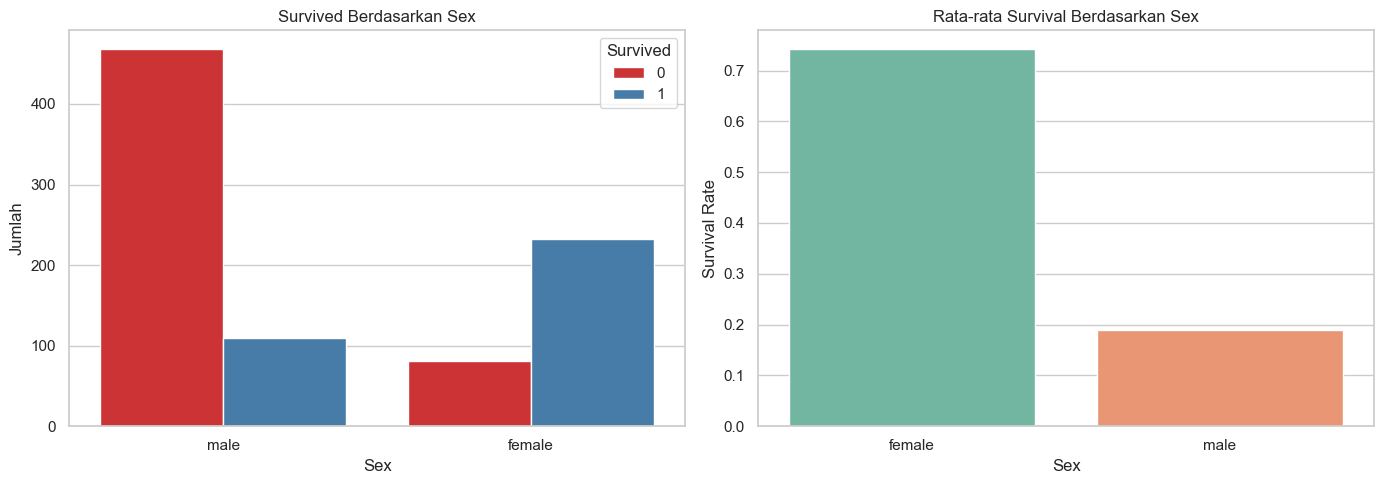

Penjelasan: Grafik ini membantu melihat apakah jenis kelamin memiliki pengaruh besar terhadap peluang selamat.


In [5]:
# Visualisasi Survived berdasarkan Sex
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=train_df, x='Sex', hue='Survived', palette='Set1', ax=axes[0])
axes[0].set_title('Survived Berdasarkan Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Jumlah')

sex_survival_rate = train_df.groupby('Sex')['Survived'].mean().reset_index()
sns.barplot(data=sex_survival_rate, x='Sex', y='Survived', palette='Set2', ax=axes[1])
axes[1].set_title('Rata-rata Survival Berdasarkan Sex')
axes[1].set_ylabel('Survival Rate')
plt.tight_layout()
plt.show()
print('Penjelasan: Grafik ini membantu melihat apakah jenis kelamin memiliki pengaruh besar terhadap peluang selamat.')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17252\1982628467.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pclass_survival_rate, x='Pclass', y='Survived', palette='Blues', ax=axes[1])


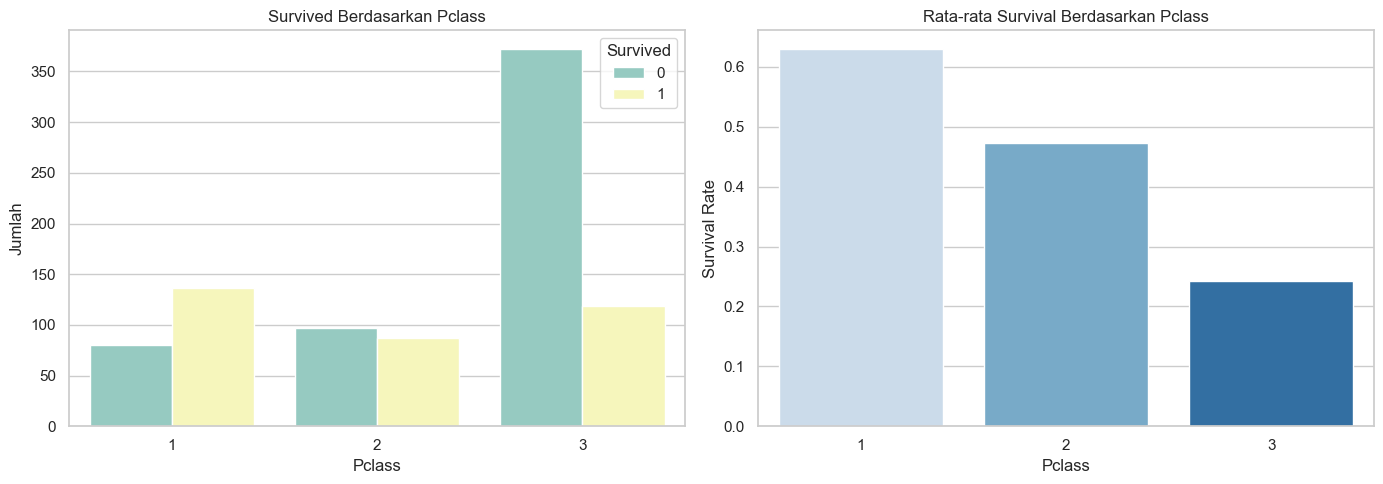

Penjelasan: Kelas penumpang sering menjadi indikator penting karena berkaitan dengan akses fasilitas dan prioritas evakuasi.


In [6]:
# Visualisasi Survived berdasarkan Pclass
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=train_df, x='Pclass', hue='Survived', palette='Set3', ax=axes[0])
axes[0].set_title('Survived Berdasarkan Pclass')
axes[0].set_xlabel('Pclass')
axes[0].set_ylabel('Jumlah')

pclass_survival_rate = train_df.groupby('Pclass')['Survived'].mean().reset_index()
sns.barplot(data=pclass_survival_rate, x='Pclass', y='Survived', palette='Blues', ax=axes[1])
axes[1].set_title('Rata-rata Survival Berdasarkan Pclass')
axes[1].set_ylabel('Survival Rate')
plt.tight_layout()
plt.show()
print('Penjelasan: Kelas penumpang sering menjadi indikator penting karena berkaitan dengan akses fasilitas dan prioritas evakuasi.')

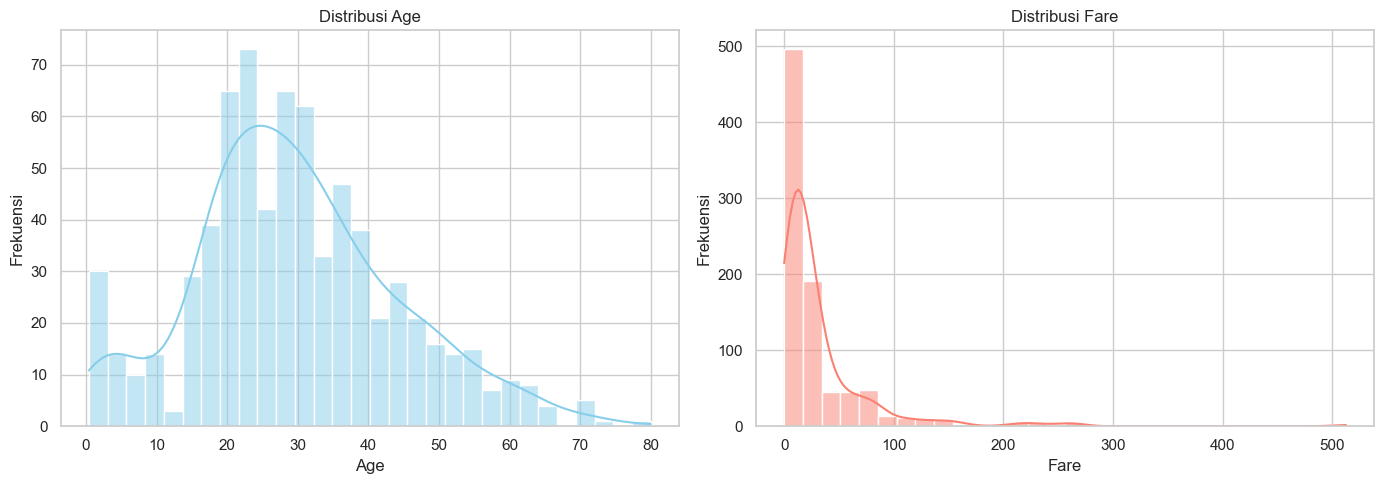

Penjelasan: Histogram Age menunjukkan sebaran umur penumpang, sedangkan Fare memperlihatkan variasi biaya tiket yang dapat berkaitan dengan kelas sosial.


In [7]:
# Histogram Age dan Fare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_df['Age'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribusi Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frekuensi')

sns.histplot(train_df['Fare'], bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribusi Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()
print('Penjelasan: Histogram Age menunjukkan sebaran umur penumpang, sedangkan Fare memperlihatkan variasi biaya tiket yang dapat berkaitan dengan kelas sosial.')

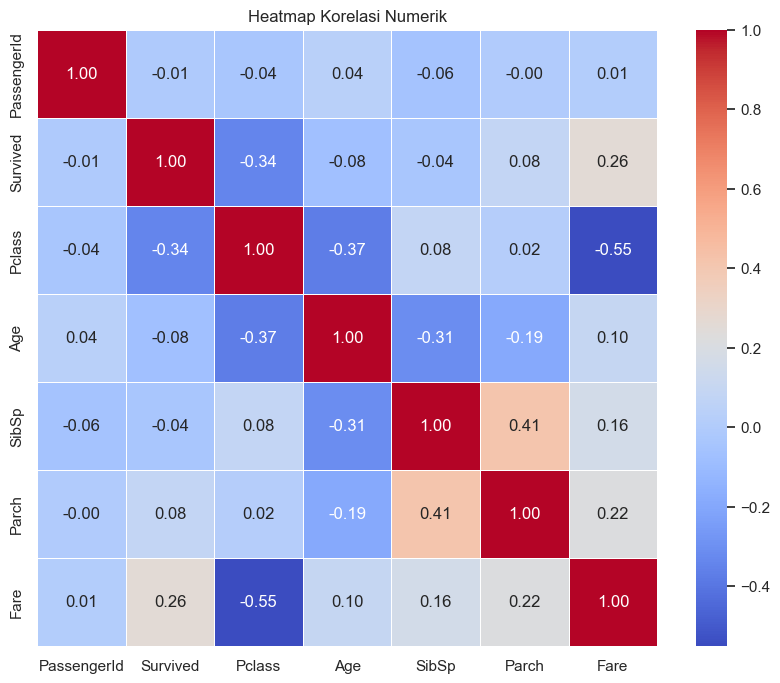

Penjelasan: Heatmap korelasi membantu melihat fitur numerik yang paling berhubungan dengan target Survived.


In [8]:
# Heatmap korelasi numerik
numeric_cols = train_df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Numerik')
plt.show()
print('Penjelasan: Heatmap korelasi membantu melihat fitur numerik yang paling berhubungan dengan target Survived.')

## D. Data Preprocessing

Pada tahap ini data dibersihkan agar siap digunakan model. Missing value diisi, kolom yang tidak relevan dihapus, dan fitur kategorikal dikonversi menjadi angka.

In [9]:
# Menyalin data agar data asli tetap aman
train_clean = train_df.copy()
test_clean = test_df.copy()

# Mengisi missing value menggunakan statistik train
age_median = train_clean['Age'].median()
fare_median = train_clean['Fare'].median()
embarked_mode = train_clean['Embarked'].mode()[0]

for df in [train_clean, test_clean]:
    df['Age'] = df['Age'].fillna(age_median)
    df['Fare'] = df['Fare'].fillna(fare_median)
    df['Embarked'] = df['Embarked'].fillna(embarked_mode)

# Menghapus kolom yang tidak digunakan
drop_cols = ['Cabin', 'Name', 'Ticket']
train_clean = train_clean.drop(columns=drop_cols)
test_clean = test_clean.drop(columns=drop_cols)

# Label encoding untuk Sex dan Embarked
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

le_sex.fit(pd.concat([train_clean['Sex'], test_clean['Sex']], axis=0))
train_clean['Sex'] = le_sex.transform(train_clean['Sex'])
test_clean['Sex'] = le_sex.transform(test_clean['Sex'])

le_embarked.fit(pd.concat([train_clean['Embarked'], test_clean['Embarked']], axis=0))
train_clean['Embarked'] = le_embarked.transform(train_clean['Embarked'])
test_clean['Embarked'] = le_embarked.transform(test_clean['Embarked'])

print('Missing values setelah preprocessing (train):')
display(train_clean.isnull().sum().to_frame('missing_values'))

print('Missing values setelah preprocessing (test):')
display(test_clean.isnull().sum().to_frame('missing_values'))

display(train_clean.head())

Missing values setelah preprocessing (train):


,missing_values
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


Missing values setelah preprocessing (test):


,missing_values
PassengerId,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,1,22.0,1,0,7.2500,2
1,2,1,1,0,38.0,1,0,71.2833,0
2,3,1,3,0,26.0,0,0,7.9250,2
3,4,1,1,0,35.0,1,0,53.1000,2
4,5,0,3,1,35.0,0,0,8.0500,2


## E. Feature Selection

Fitur yang digunakan adalah `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, dan `Embarked`. Target yang diprediksi adalah `Survived`.

In [10]:
# Memilih fitur dan target
selected_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = train_clean[selected_features]
y = train_clean['Survived']
X_test_submission = test_clean[selected_features]

print('Shape fitur X:', X.shape)
print('Shape target y:', y.shape)
display(X.head())

Shape fitur X: (891, 7)
Shape target y: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2


## F. Train Test Split

Data dibagi menjadi data training dan testing dengan komposisi 80:20 agar performa model dapat dievaluasi pada data yang belum pernah dilihat sebelumnya.

In [11]:
# Membagi data train dan test
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train shape:', X_train.shape)
print('X_val shape:', X_val.shape)
print('y_train shape:', y_train.shape)
print('y_val shape:', y_val.shape)

X_train shape: (712, 7)
X_val shape: (179, 7)
y_train shape: (712,)
y_val shape: (179,)


## G. Machine Learning Model

Tiga algoritma dibandingkan dalam proyek ini, yaitu Logistic Regression, Decision Tree Classifier, dan Random Forest Classifier.

In [13]:
# Melatih dan mengevaluasi beberapa model
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []
trained_models = {}
confusion_matrices = {}
reports = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    cm = confusion_matrix(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=False)

    trained_models[name] = model
    confusion_matrices[name] = cm
    reports[name] = report
    results.append({'Model': name, 'Accuracy': acc})

    print('=' * 60)
    print(name)
    print('Accuracy:', round(acc, 4))
    print('Confusion Matrix:\n', cm)
    print('Classification Report:\n', report)

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

Logistic Regression
Accuracy: 0.8045
Confusion Matrix:
 [[98 12]
 [23 46]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

Decision Tree Classifier
Accuracy: 0.8324
Confusion Matrix:
 [[97 13]
 [17 52]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.87       110
           1       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

Random Forest Classifier
Accuracy: 0.8324
Confusion Matrix:
 [[98 12]
 [18 51]]
Classification Report:
               precision    recall  f1-s

,Model,Accuracy
0,Decision Tree Classifier,0.832402
1,Random Forest Classifier,0.832402
2,Logistic Regression,0.804469


## H. Evaluation

Hasil evaluasi dibandingkan menggunakan accuracy, confusion matrix, dan classification report. Tabel ringkasan memudahkan perbandingan performa antarmodel.

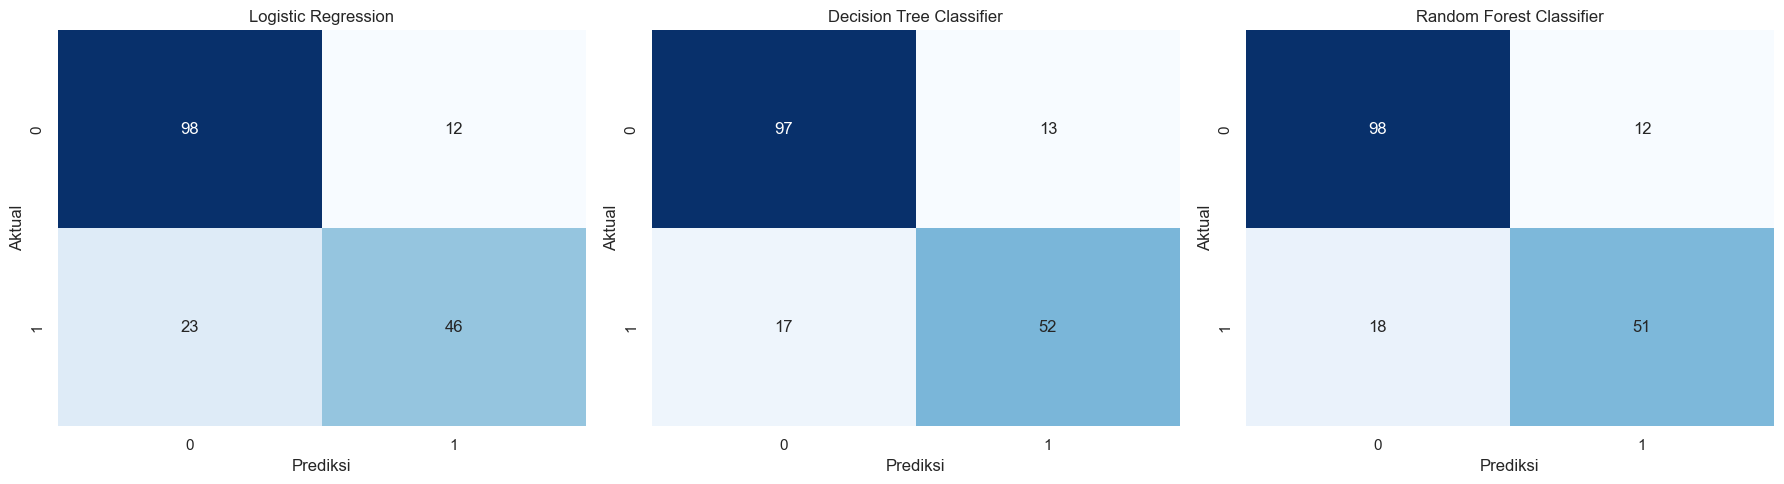

Tabel perbandingan model:


,Model,Accuracy
0,Decision Tree Classifier,0.832402
1,Random Forest Classifier,0.832402
2,Logistic Regression,0.804469


In [14]:
# Menampilkan confusion matrix untuk setiap model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.tight_layout()
plt.show()

print('Tabel perbandingan model:')
display(results_df)

## I. Model Comparison

Model terbaik dipilih berdasarkan nilai accuracy tertinggi pada data validasi. Setelah itu, model terbaik akan dilatih ulang menggunakan seluruh data training sebelum digunakan untuk prediksi data test.

In [15]:
# Menentukan model terbaik
best_row = results_df.iloc[0]
best_model_name = best_row['Model']
best_accuracy = best_row['Accuracy']
best_model = trained_models[best_model_name]

print('Model terbaik:', best_model_name)
print('Accuracy terbaik:', round(best_accuracy, 4))
print('Analisis singkat: model dengan accuracy tertinggi dipilih karena paling baik dalam memprediksi data validasi. Pada data Titanic, fitur seperti Sex dan Pclass biasanya memberi sinyal yang kuat terhadap survival.')

Model terbaik: Decision Tree Classifier
Accuracy terbaik: 0.8324
Analisis singkat: model dengan accuracy tertinggi dipilih karena paling baik dalam memprediksi data validasi. Pada data Titanic, fitur seperti Sex dan Pclass biasanya memberi sinyal yang kuat terhadap survival.


## J. Prediction

Pada tahap ini model terbaik dilatih ulang dengan seluruh data latih, kemudian digunakan untuk memprediksi data `test.csv`. Hasil prediksi disimpan ke file `submission.csv` sesuai format Kaggle.

In [16]:
# Melatih ulang model terbaik dengan seluruh data training
best_model.fit(X, y)

# Prediksi data test
test_predictions = best_model.predict(X_test_submission)

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': test_predictions.astype(int)
})

submission.to_csv('submission.csv', index=False)
print('File submission.csv berhasil dibuat.')
display(submission.head())

File submission.csv berhasil dibuat.


,PassengerId,Survived
0,892,0
1,893,0
2,894,1
3,895,1
4,896,1


## Kesimpulan

- Jumlah data train adalah **891** baris dan jumlah data test adalah **418** baris.
- Setelah preprocessing, missing value pada `Age`, `Fare`, dan `Embarked` sudah diisi, sedangkan kolom `Cabin`, `Name`, dan `Ticket` dihapus. Fitur kategorikal `Sex` dan `Embarked` juga sudah di-encoding.
- Model terbaik pada validasi adalah **Decision Tree Classifier** dengan accuracy **0.8324**. Random Forest Classifier memiliki accuracy yang sama, sehingga performanya sangat dekat.
- Nilai accuracy terbaik adalah **0.8324**.
- Berdasarkan EDA, faktor yang paling berpengaruh terhadap survival adalah `Sex` dan `Pclass`. Penumpang perempuan memiliki survival rate jauh lebih tinggi daripada laki-laki, dan penumpang kelas 1 juga memiliki peluang selamat lebih besar dibanding kelas 2 dan 3.